In [1]:
%matplotlib widget
from orix.io import load
import matplotlib.pyplot as plt
import numpy as np
import hyperspy.api as hs
from orix.plot import IPFColorKeyTSL

from orix.quaternion import Symmetry

# from orix.symmetry import Oh  # cubic (m-3m, fcc Pt)
import os, glob
import pandas as pd

import orix
orix.__version__

import matplotlib.pyplot as plt

from orix.plot import IPFColorKeyTSL


from orix.quaternion import Rotation
from orix import data
from orix.plot import register_projections
from orix.vector import Vector3d

In [2]:
base_path = '/dls/e02/data/2026/cm44133-1/processing/Merlin/Pt_NP_24Feb_Overnight/'
ang_files = sorted(glob.glob(base_path + '/*/ACOM_array/*.ang'))
len(ang_files)

153

## Test on one dataset

In [3]:
# path = '/dls/e02/data/2026/cm44133-1/processing/Merlin/Pt_NP_24Feb_Overnight/20260224_203557/ACOM_array/orientation_map_crystal.ang'
# d = load(path)



# mask_files = sorted(glob.glob(base_path + '/*/mask.npy'))

index = 2
# # _mask = np.load(mask_files[index])

# print(mask_files[index])
print(ang_files[index])

d = load(ang_files[index])

print(ang_files[index])



# Read file, ignore header lines beginning with ##
df = pd.read_csv(
    ang_files[index],
    sep=r"\s+",     # ← any whitespace
    comment="#",
    header=None,
    engine="python"
)

# # Assign column names manually (from your file)
df.columns = [
    "phi1", "Phi", "phi2",
    "x", "y",
    "image_quality",
    "confidence_index",
    "phase_id",
    "detector_signal",
    "pattern_fit"
]

# print(df.head())


ci = df["confidence_index"].values

ci_reshaped = np.reshape(ci, (255,255))
_mask = ci_reshaped > 0.1

/dls/e02/data/2026/cm44133-1/processing/Merlin/Pt_NP_24Feb_Overnight/20260224_163951/ACOM_array/orientation_map_crystal.ang
autogenerating phase names...
Changing Phase 1 name from 'Pt' to 'Pt'
/dls/e02/data/2026/cm44133-1/processing/Merlin/Pt_NP_24Feb_Overnight/20260224_163951/ACOM_array/orientation_map_crystal.ang


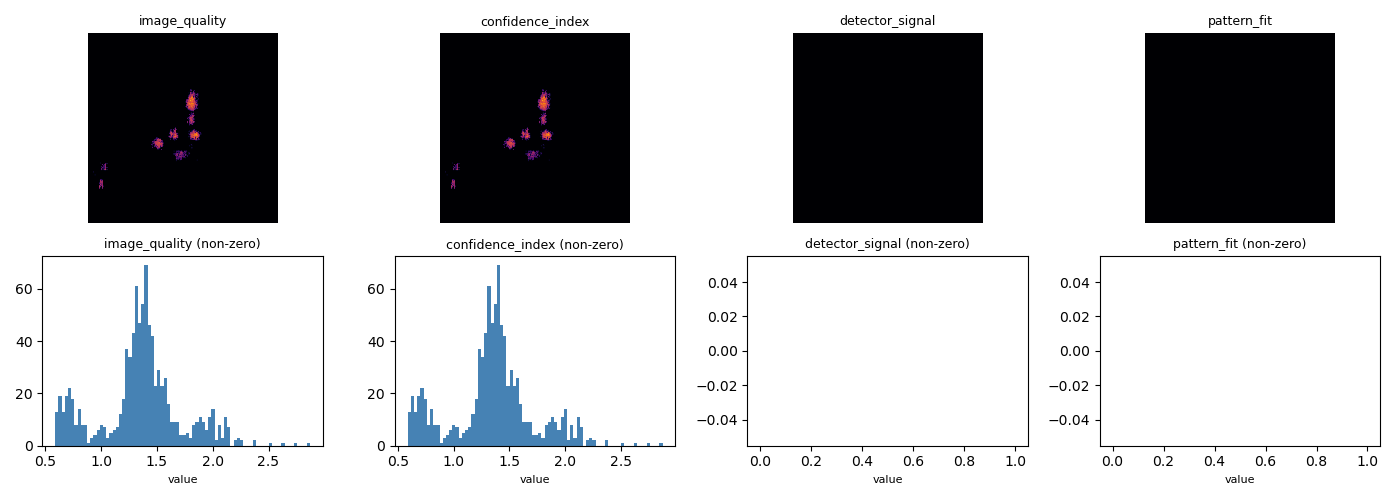

In [4]:
from skimage.filters import threshold_otsu
from skimage import morphology as skmorph

# ── All four ACOM quality signals reshaped to 2-D ──────────────────────────
iq  = df["image_quality"].values.reshape(255, 255)
ci  = df["confidence_index"].values.reshape(255, 255)
ds  = df["detector_signal"].values.reshape(255, 255)
fit = df["pattern_fit"].values.reshape(255, 255)

# Quick look at distributions so we can judge which separates vacuum vs particle
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, data_2d, name in zip(
        axes[0],
        [iq, ci, ds, fit],
        ["image_quality", "confidence_index", "detector_signal", "pattern_fit"]):
    ax.imshow(data_2d, cmap="inferno")
    ax.set_title(name, fontsize=9)
    ax.axis("off")

for ax, data_2d, name in zip(
        axes[1],
        [iq, ci, ds, fit],
        ["image_quality", "confidence_index", "detector_signal", "pattern_fit"]):
    vals = data_2d.ravel()
    vals = vals[vals > 0]          # ignore exact zeros (vacuum)
    ax.hist(vals, bins=80, color="steelblue", edgecolor="none")
    ax.set_title(f"{name} (non-zero)", fontsize=9)
    ax.set_xlabel("value", fontsize=8)

plt.tight_layout()
plt.show()

# detectpr signal and pattern fit are empty

Otsu threshold on IQ×CI quality score: 0.1387


/tmp/ipykernel_353991/540735150.py:18: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
/tmp/ipykernel_353991/540735150.py:19: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_holes(particle_mask, area_thre

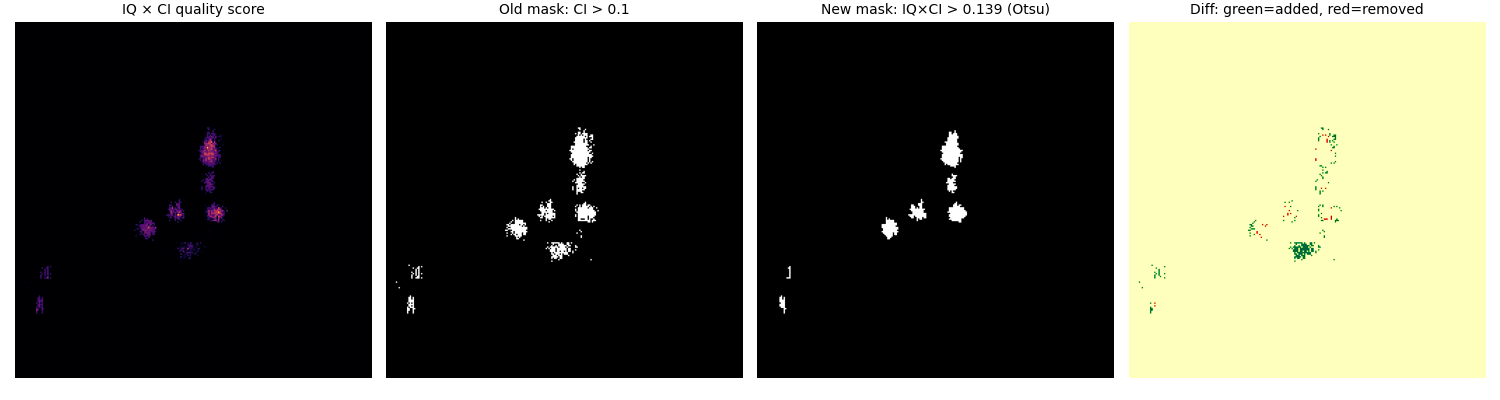

Pixels kept — old: 927  new: 702  change: -225


In [5]:
# ── Improved mask: combined IQ × CI quality score ──────────────────────────
#
# detector_signal and pattern_fit are empty in these files, so we combine
# image_quality and confidence_index.  Their product is near-zero whenever
# either is near-zero (vacuum), and only large when both are high (particle).
# A single Otsu threshold on the product adapts to each dataset automatically.

# Normalise each to [0, 1] so their scales don't bias the product
iq_norm = iq / iq.max() if iq.max() > 0 else iq
ci_norm = ci / ci.max() if ci.max() > 0 else ci

quality = iq_norm * ci_norm   # combined score: 0 in vacuum, high on particles

q_thresh = threshold_otsu(quality)
print(f"Otsu threshold on IQ×CI quality score: {q_thresh:.4f}")

particle_mask = quality > q_thresh
particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
particle_mask = skmorph.remove_small_holes(particle_mask, area_threshold=10)

# ── Comparison: old single-threshold vs new combined mask ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(quality, cmap="inferno")
axes[0].set_title("IQ × CI quality score", fontsize=10)

axes[1].imshow(ci > 0.1, cmap="gray")
axes[1].set_title("Old mask: CI > 0.1", fontsize=10)

axes[2].imshow(particle_mask, cmap="gray")
axes[2].set_title(f"New mask: IQ×CI > {q_thresh:.3f} (Otsu)", fontsize=10)

axes[3].imshow((ci > 0.1).astype(int) - particle_mask.astype(int),
               cmap="RdYlGn", vmin=-1, vmax=1)
axes[3].set_title("Diff: green=added, red=removed", fontsize=10)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Pixels kept — old: {(ci > 0.1).sum()}  new: {particle_mask.sum()}  "
      f"change: {particle_mask.sum() - (ci > 0.1).sum():+d}")

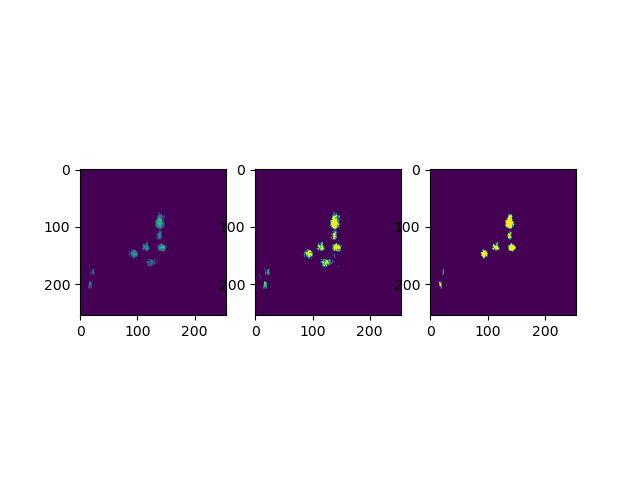

In [6]:
fig, axs = plt.subplots(1,3)
axs[0].imshow(ci_reshaped)
axs[1].imshow(_mask)
axs[2].imshow(particle_mask)

In [7]:
ori = d.orientations

In [8]:
print(d.phases)

Id  Name  Space group  Point group  Proper point group     Color
 1    Pt         None          432                 432  tab:blue


In [9]:
d.phases.point_groups

[Symmetry (24,) 432
 [[ 1.      0.      0.      0.    ]
  [ 0.7071  0.      0.      0.7071]
  [ 0.      0.      0.      1.    ]
  [-0.7071  0.      0.      0.7071]
  [ 0.5     0.5     0.5     0.5   ]
  [ 0.      0.      0.7071  0.7071]
  [-0.5    -0.5     0.5     0.5   ]
  [-0.7071 -0.7071  0.      0.    ]
  [ 0.      1.      0.      0.    ]
  [ 0.      0.7071  0.7071  0.    ]
  [ 0.      0.      1.      0.    ]
  [ 0.     -0.7071  0.7071  0.    ]
  [-0.5     0.5     0.5    -0.5   ]
  [ 0.      0.      0.7071 -0.7071]
  [ 0.5    -0.5     0.5    -0.5   ]
  [ 0.7071 -0.7071  0.      0.    ]
  [ 0.      0.7071  0.      0.7071]
  [-0.5     0.5     0.5     0.5   ]
  [-0.7071  0.      0.7071  0.    ]
  [-0.5    -0.5     0.5    -0.5   ]
  [ 0.      0.7071  0.     -0.7071]
  [ 0.5     0.5     0.5    -0.5   ]
  [ 0.7071  0.      0.7071  0.    ]
  [ 0.5    -0.5     0.5     0.5   ]]]

In [10]:
sym = d.phases.point_groups[0]

In [11]:
sym

Symmetry (24,) 432
[[ 1.      0.      0.      0.    ]
 [ 0.7071  0.      0.      0.7071]
 [ 0.      0.      0.      1.    ]
 [-0.7071  0.      0.      0.7071]
 [ 0.5     0.5     0.5     0.5   ]
 [ 0.      0.      0.7071  0.7071]
 [-0.5    -0.5     0.5     0.5   ]
 [-0.7071 -0.7071  0.      0.    ]
 [ 0.      1.      0.      0.    ]
 [ 0.      0.7071  0.7071  0.    ]
 [ 0.      0.      1.      0.    ]
 [ 0.     -0.7071  0.7071  0.    ]
 [-0.5     0.5     0.5    -0.5   ]
 [ 0.      0.      0.7071 -0.7071]
 [ 0.5    -0.5     0.5    -0.5   ]
 [ 0.7071 -0.7071  0.      0.    ]
 [ 0.      0.7071  0.      0.7071]
 [-0.5     0.5     0.5     0.5   ]
 [-0.7071  0.      0.7071  0.    ]
 [-0.5    -0.5     0.5    -0.5   ]
 [ 0.      0.7071  0.     -0.7071]
 [ 0.5     0.5     0.5    -0.5   ]
 [ 0.7071  0.      0.7071  0.    ]
 [ 0.5    -0.5     0.5     0.5   ]]

In [12]:
d.orientations.symmetry = sym

In [13]:
ipf_key = IPFColorKeyTSL(sym, direction=[0,0,1])

In [14]:
d.phases[1]

<name: Pt. space group: None. point group: 432. proper point group: 432. color: tab:blue>

Phase    Orientations  Name  Space group  Point group  Proper point group     Color
    1  65025 (100.0%)    Pt         None          432                 432  tab:blue
Properties: iq, ci, detector_signal, fit
Scan unit: um


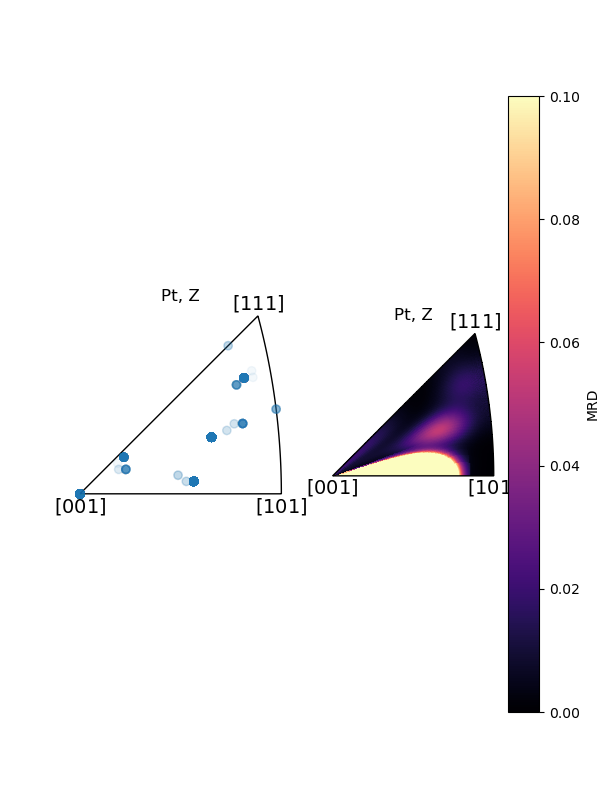

In [15]:
# Without masking
import matplotlib.pyplot as plt

register_projections()  # Register our custom Matplotlib projections

xmap = d  
print(xmap)

# Extract orientations, O
pg_m3m = xmap.phases[1].point_group.laue
Pt = xmap["Pt"].orientations

# Some sample direction, v
v = Vector3d([0, 0, 1])
v_title = "Z"

# Rotate sample direction v into every crystal orientation O
t_pt = Pt * v


# Set IPDF range
vmin, vmax = (0, .1)

subplot_kw = {"projection": "ipf", "symmetry": pg_m3m, "direction": v}
fig = plt.figure(figsize=(6, 8))

ax0 = fig.add_subplot(121, **subplot_kw)
ax0.scatter(Pt, alpha=0.05)
_ = ax0.set_title(f"Pt, {v_title}")



ax2 = fig.add_subplot(122, **subplot_kw)
ax2.pole_density_function(t_pt, vmin=vmin, vmax=vmax)
_ = ax2.set_title(f"Pt, {v_title}")



In [16]:
xmap["Pt"].prop

{'iq': array([0., 0., 0., ..., 0., 0., 0.], shape=(65025,)),
 'ci': array([0., 0., 0., ..., 0., 0., 0.], shape=(65025,)),
 'detector_signal': array([0., 0., 0., ..., 0., 0., 0.], shape=(65025,)),
 'fit': array([0., 0., 0., ..., 0., 0., 0.], shape=(65025,))}

In [17]:
_mask.shape

(255, 255)

/tmp/ipykernel_353991/2885132458.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


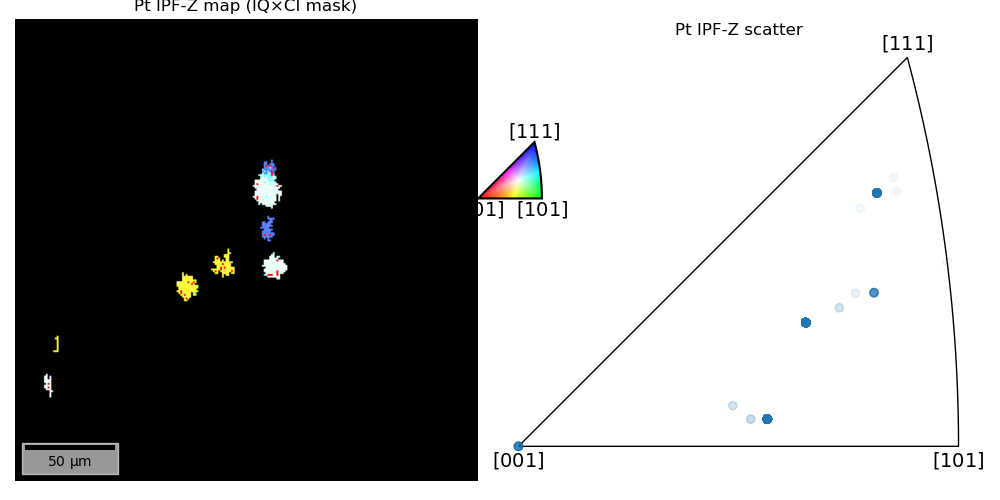

In [18]:
register_projections()

xmap = d
phase = xmap.phases[1]
sym   = phase.point_group.laue
v     = Vector3d([0, 0, 1])

# ── Mask: True = particle pixel to keep ────────────────────────────────────
# particle_mask was computed in the cell above using IQ×CI + Otsu.
# Flatten to 1-D so it indexes into the orientation array directly.
keep = particle_mask.flatten()   # True = keep, False = background

# ── IPF colouring ──────────────────────────────────────────────────────────
O    = xmap["Pt"].orientations
ckey = IPFColorKeyTSL(sym, direction=v)
rgb  = ckey.orientation2color(O).reshape(255, 255, 3)

rgb_masked = rgb.copy()
rgb_masked[~particle_mask] = 0   # black background

# ── Figure ─────────────────────────────────────────────────────────────────
subplot_kw = {"projection": "ipf", "symmetry": sym, "direction": v}
fig = plt.figure(figsize=(10, 5))

ax0 = fig.add_subplot(121, projection="plot_map")
ax0.plot_map(xmap["Pt"], rgb_masked.reshape(-1, 3))
ax0.set_title("Pt IPF-Z map (IQ×CI mask)")
ax0.remove_padding()

ax1 = fig.add_subplot(122, **subplot_kw)
ax1.scatter(O.flatten()[keep], alpha=0.05)
ax1.set_title(f"Pt IPF-Z scatter")

ax_ckey = fig.add_axes(
    [0.45, 0.6, 0.12, 0.12],
    projection="ipf", symmetry=sym, zorder=2
)
ax_ckey.plot_ipf_color_key(show_title=False)
ax_ckey.patch.set_facecolor("none")

plt.tight_layout()
plt.show()

## Plotting this over multiple datasets



In [19]:
from skimage.filters import threshold_otsu
from skimage import morphology as skmorph

all_orientations = []

for i, _f in enumerate(ang_files):
    d = load(_f)

    df = pd.read_csv(
        _f, sep=r"\s+", comment="#",
        header=None, engine="python"
    )
    df.columns = [
        "phi1", "Phi", "phi2", "x", "y",
        "image_quality", "confidence_index",
        "phase_id", "detector_signal", "pattern_fit"
    ]

    iq = df["image_quality"].values.reshape(255, 255)
    ci = df["confidence_index"].values.reshape(255, 255)

    iq_norm = iq / iq.max() if iq.max() > 0 else iq
    ci_norm = ci / ci.max() if ci.max() > 0 else ci
    quality  = iq_norm * ci_norm

    thresh        = threshold_otsu(quality)
    particle_mask = quality > thresh
    particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
    particle_mask = skmorph.remove_small_holes(particle_mask, area_threshold=10)

    keep  = particle_mask.flatten()
    O     = d["Pt"].orientations
    all_orientations.append(O.flatten()[keep])

    if (i + 1) % 10 == 0 or i == len(ang_files) - 1:
        print(f"  {i+1}/{len(ang_files)} done")

print("Loaded all datasets.")

autogenerating phase names...
Changing Phase 1 name from 'Pt' to 'Pt'


/tmp/ipykernel_353991/2737667186.py:28: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
/tmp/ipykernel_353991/2737667186.py:29: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_holes(particle_mask, area_th

autogenerating phase names...
Changing Phase 1 name from 'Pt' to 'Pt'


/tmp/ipykernel_353991/2737667186.py:28: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
/tmp/ipykernel_353991/2737667186.py:29: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_holes(particle_mask, area_th

autogenerating phase names...
Changing Phase 1 name from 'Pt' to 'Pt'


...

/tmp/ipykernel_353991/2737667186.py:28: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
/tmp/ipykernel_353991/2737667186.py:29: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_holes(particle_mask, area_th

autogenerating phase names...
Changing Phase 1 name from 'Pt' to 'Pt'


/tmp/ipykernel_353991/2737667186.py:28: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
/tmp/ipykernel_353991/2737667186.py:29: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_holes(particle_mask, area_th

autogenerating phase names...
Changing Phase 1 name from 'Pt' to 'Pt'
  153/153 done
Loaded all datasets.


/tmp/ipykernel_353991/2737667186.py:28: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
/tmp/ipykernel_353991/2737667186.py:29: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_holes(particle_mask, area_th

/tmp/ipykernel_353991/1578790880.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


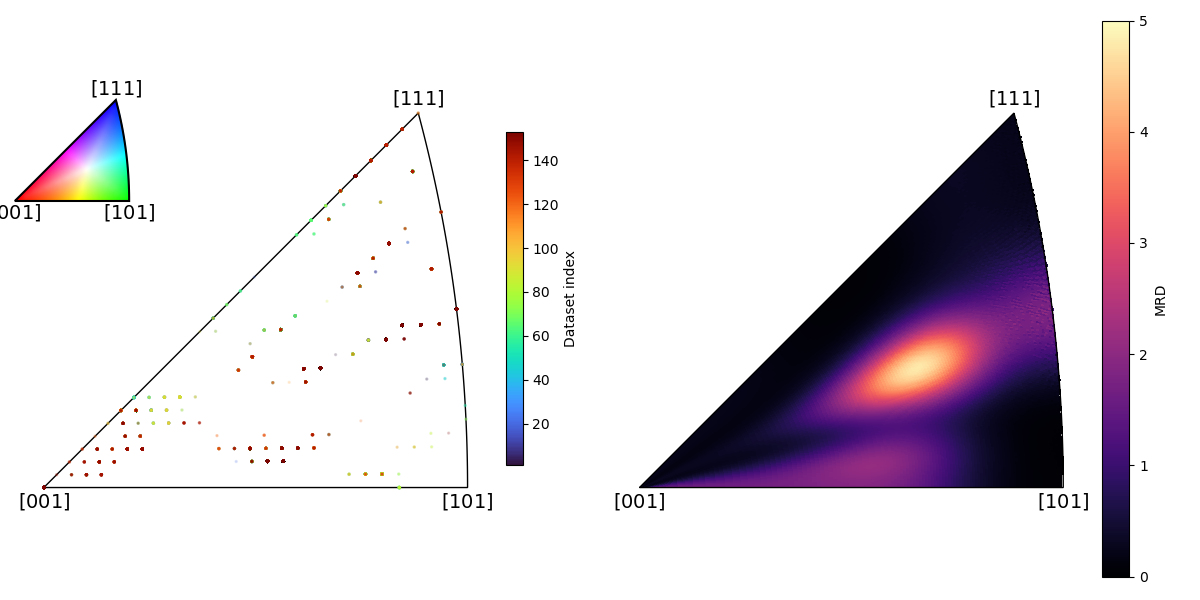

In [20]:
register_projections()

# Use symmetry from the last loaded dataset (same for all — Pt cubic)
sym = d.phases[1].point_group.laue
v   = Vector3d([0, 0, 1])
subplot_kw = {"projection": "ipf", "symmetry": sym, "direction": v}

n    = len(all_orientations)
cmap = plt.cm.turbo

fig, axes = plt.subplots(1, 2, figsize=(12, 6),
                          subplot_kw=subplot_kw)

# ── Left: scatter coloured by dataset index ────────────────────────────────
for i, O_i in enumerate(all_orientations):
    color = cmap(i / (n - 1))
    axes[0].scatter(O_i, c=[color] * len(O_i.data), alpha=0.15, s=2)

# axes[0].set_title(f"All {n} datasets — coloured by acquisition order",
#                   fontsize=10)

# Colourbar showing dataset index
sm = plt.cm.ScalarMappable(cmap=cmap,
                            norm=plt.Normalize(vmin=1, vmax=n))
sm.set_array([])
plt.colorbar(sm, ax=axes[0], label="Dataset index", shrink=0.6, pad=0.05)

# ── Right: density (all orientations pooled) ──────────────────────────────
from orix.quaternion import Rotation
import numpy as np

all_quats = np.concatenate([O_i.data for O_i in all_orientations], axis=0)
O_all     = Rotation(all_quats)
O_all.symmetry = sym
t_all     = O_all * v

axes[1].pole_density_function(t_all, vmin=0, vmax=5)
# axes[1].set_title("Pooled pole density (all datasets)", fontsize=14)

# ── IPF colour key inset on left panel ────────────────────────────────────
ax_key = fig.add_axes([0.01, 0.65, 0.10, 0.20],
                       projection="ipf", symmetry=sym)
ax_key.plot_ipf_color_key(show_title=False)
ax_key.patch.set_facecolor("none")

plt.tight_layout()
plt.show()

In [39]:
fig.savefig('pooled_orientations_all_datasets.png',dpi=300)

# Link between morphology and orientation

In [21]:
from skimage import measure as skmeasure
from skimage import morphology as skmorph, filters as skfilters
from skimage.segmentation import clear_border
from orix.quaternion import Rotation, Orientation
from orix.vector import Vector3d
import pandas as pd
import numpy as np

# Real-space pixel size — adjust if different
ROI_NM_PER_PIXEL = 52.08 / 10   # Angstrom → nm  (probe step from run1_analysis)
AREA_PER_PIXEL   = ROI_NM_PER_PIXEL ** 2  # nm²

records = []

for i, _f in enumerate(ang_files):
    d  = load(_f)
    df = pd.read_csv(_f, sep=r"\s+", comment="#",
                     header=None, engine="python")
    df.columns = ["phi1","Phi","phi2","x","y",
                  "image_quality","confidence_index",
                  "phase_id","detector_signal","pattern_fit"]

    iq = df["image_quality"].values.reshape(255, 255)
    ci = df["confidence_index"].values.reshape(255, 255)

    iq_norm  = iq / iq.max() if iq.max() > 0 else iq
    ci_norm  = ci / ci.max() if ci.max() > 0 else ci
    quality  = iq_norm * ci_norm

    thresh        = skfilters.threshold_otsu(quality)
    particle_mask = quality > thresh
    particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
    particle_mask = skmorph.remove_small_holes(particle_mask, area_threshold=10)
    particle_mask = clear_border(particle_mask)

    labels = skmeasure.label(particle_mask)
    props  = skmeasure.regionprops(labels)

    # Quaternion array (255×255, 4)
    sym   = d.phases[1].point_group.laue
    O_2d  = d["Pt"].orientations.data.reshape(255, 255, 4)

    for prop in props:
        pix_mask = labels == prop.label          # (255,255) bool

        # Only keep pixels that also pass the quality mask & have valid CI
        valid = pix_mask & (ci > 0)
        if valid.sum() < 3:                      # skip tiny / low-quality particles
            continue

        # Mean orientation via mean quaternion (handles cubic symmetry well enough
        # for a summary; use Orientation.mean() if orix version supports it)
        quats    = O_2d[valid]                   # (N, 4)
        O_p      = Rotation(quats)
        O_p.symmetry = sym
        mean_ori = O_p.mean()                    # single mean rotation

        # Mean CI as a quality indicator for this particle
        mean_ci  = ci[valid].mean()

        records.append({
            "dataset":        i,
            "particle_label": prop.label,
            "area_nm2":       prop.area * AREA_PER_PIXEL,
            "eccentricity":   prop.eccentricity,
            "aspect_ratio":   prop.axis_major_length / max(prop.axis_minor_length, 1e-6),
            "mean_ci":        mean_ci,
            "n_pixels":       int(valid.sum()),
            "mean_ori":       mean_ori,           # Rotation object stored per row
        })

    if (i + 1) % 10 == 0 or i == len(ang_files) - 1:
        print(f"  {i+1}/{len(ang_files)}  particles so far: {len(records)}")

particle_df = pd.DataFrame(records)
print(f"\nTotal particles: {len(particle_df)}")
particle_df.head()

autogenerating phase names...
Changing Phase 1 name from 'Pt' to 'Pt'


/tmp/ipykernel_353991/3382963489.py:32: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
/tmp/ipykernel_353991/3382963489.py:33: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_holes(particle_mask, area_th

autogenerating phase names...
Changing Phase 1 name from 'Pt' to 'Pt'


/tmp/ipykernel_353991/3382963489.py:32: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
/tmp/ipykernel_353991/3382963489.py:33: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_holes(particle_mask, area_th

autogenerating phase names...
Changing Phase 1 name from 'Pt' to 'Pt'


...

autogenerating phase names...
Changing Phase 1 name from 'Pt' to 'Pt'


/tmp/ipykernel_353991/3382963489.py:32: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
/tmp/ipykernel_353991/3382963489.py:33: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_holes(particle_mask, area_th

autogenerating phase names...
Changing Phase 1 name from 'Pt' to 'Pt'
  153/153  particles so far: 510

Total particles: 510


/tmp/ipykernel_353991/3382963489.py:32: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_objects(particle_mask, min_size=10)
/tmp/ipykernel_353991/3382963489.py:33: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  particle_mask = skmorph.remove_small_holes(particle_mask, area_th

,dataset,particle_label,area_nm2,eccentricity,aspect_ratio,mean_ci,n_pixels,mean_ori
0,0,1,7838.623296,0.524533,1.174550,1.497965,282,"Rotation (1,)\n[[-0.9627 -0.2231 -0.0387 -0.14..."
1,0,2,1112.053824,0.366826,1.074934,1.412505,39,"Rotation (1,)\n[[-0.882 -0.2132 0.0824 -0.41..."
2,0,3,678.081600,0.803164,1.678535,1.394678,25,"Rotation (1,)\n[[ 0.0706 -0.3957 0.8888 0.22..."
3,0,4,488.218752,0.658960,1.329473,1.409061,18,"Rotation (1,)\n[[0.7542 0.3854 0.0098 0.5315]]"
4,0,5,6726.569472,0.476872,1.137692,1.641934,243,"Rotation (1,)\n[[-0.7711 -0.4305 -0.0345 -0.46..."


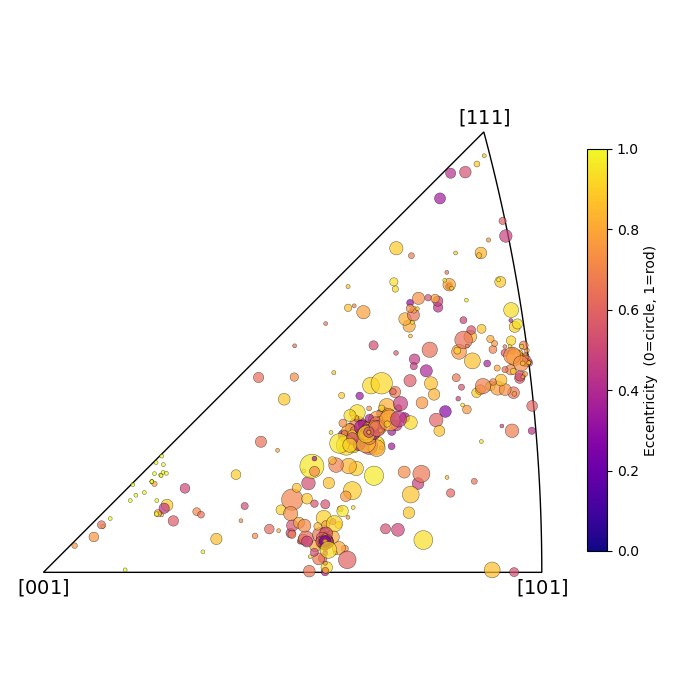

In [22]:
register_projections()

sym = d.phases[1].point_group.laue
v   = Vector3d([0, 0, 1])

mean_oris = Rotation(
    np.stack([r.data.squeeze() for r in particle_df["mean_ori"]])
)
mean_oris.symmetry = sym

areas = particle_df["area_nm2"].values
eccs  = particle_df["eccentricity"].values

# Normalise marker size so the largest particle is ~300 pt²
s_scale = 300 / areas.max()
sizes   = np.clip(areas * s_scale, 8, 300)

ecc_norm = plt.Normalize(vmin=0, vmax=1)
ecc_cmap = plt.cm.plasma
colors   = ecc_cmap(ecc_norm(eccs))

fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, projection="ipf", symmetry=sym, direction=v)

ax.scatter(
    mean_oris,
    s=sizes,
    c=colors,
    alpha=0.7,
    linewidths=0.3,
    edgecolors="k",
)

# Explicit ScalarMappable for the colorbar — avoids the orix return-value issue
sm = plt.cm.ScalarMappable(cmap=ecc_cmap, norm=ecc_norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Eccentricity  (0=circle, 1=rod)",
             shrink=0.6, pad=0.05)

# ax.set_title("Per-particle IPF-Z\n"
#              "position = orientation · size = area · colour = eccentricity",
#              fontsize=10)

for ref_area in [50, 200, 500]:
    ax.scatter([], [], s=ref_area * s_scale,
               c="grey", alpha=0.6, edgecolors="k", linewidths=0.3,
               label=f"{ref_area} nm²")
# ax.legend(title="Area", fontsize=8, title_fontsize=8,
#           loc="lower right", framealpha=0.8)

plt.tight_layout()
plt.show()

In [41]:
fig.savefig('Orientation_linked_area_shape.png',dpi=300)

/tmp/ipykernel_353991/2239065139.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=particle_df, x="pole_group", y=y_col,
/tmp/ipykernel_353991/2239065139.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=particle_df, x="pole_group", y=y_col,
/tmp/ipykernel_353991/2239065139.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=particle_df, x="pole_group", y=y_col,
/tmp/ipykernel_353991/2239065139.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x

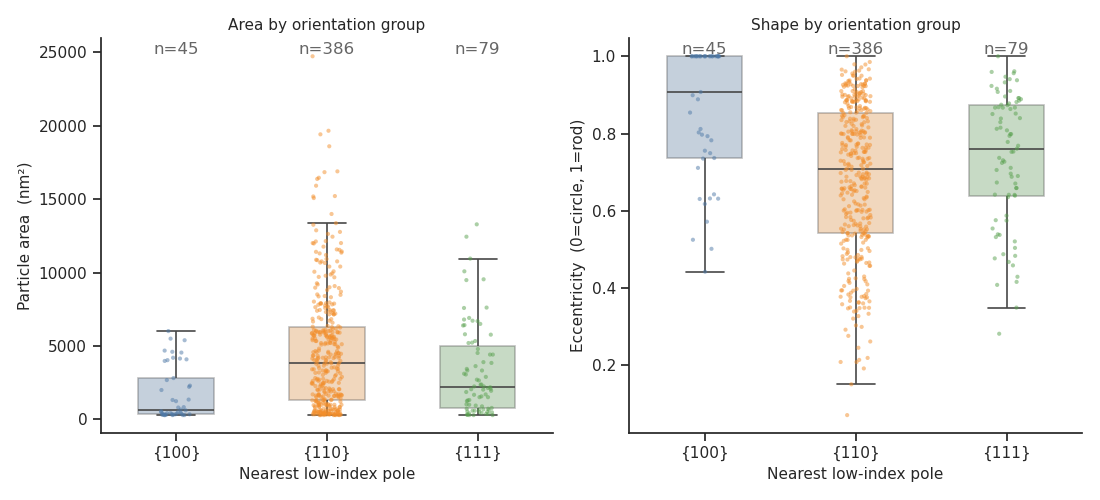

In [23]:
import seaborn as sns

low_index_poles = {
    "{100}": Vector3d([[1,0,0],[0,1,0],[0,0,1]]),
    "{110}": Vector3d([[1,1,0],[1,0,1],[0,1,1],
                       [-1,1,0],[-1,0,1],[0,-1,1]]) / np.sqrt(2),
    "{111}": Vector3d([[1,1,1],[1,1,-1],[1,-1,1],[-1,1,1]]) / np.sqrt(3),
}

def nearest_pole(mean_rot, sym):
    v_crystal = mean_rot * Vector3d([0, 0, 1])
    best_label, best_cos = "{100}", -1.0
    for label, poles in low_index_poles.items():
        cos_vals = np.abs(v_crystal.data @ poles.data.T)
        if cos_vals.max() > best_cos:
            best_cos   = cos_vals.max()
            best_label = label
    return best_label

particle_df["pole_group"] = [
    nearest_pole(r, sym) for r in particle_df["mean_ori"]
]

pole_order = ["{100}", "{110}", "{111}"]
palette    = dict(zip(pole_order, ["#4e79a7", "#f28e2b", "#59a14f"]))
BOX_ALPHA  = 0.35   # ← adjust box fill transparency here

sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, y_col, ylabel, title in [
    (axes[0], "area_nm2",     r"Particle area  (nm²)",           "Area by orientation group"),
    (axes[1], "eccentricity", "Eccentricity  (0=circle, 1=rod)", "Shape by orientation group"),
]:
    sns.boxplot(data=particle_df, x="pole_group", y=y_col,
                order=pole_order, palette=palette,
                width=0.5, linewidth=1.2,
                fliersize=0,   # hide flier markers — stripplot already shows them
                ax=ax)

    # Set box face alpha after the fact (boxplot has no direct alpha kwarg)
    for patch in ax.patches:
        patch.set_alpha(BOX_ALPHA)

    sns.stripplot(data=particle_df, x="pole_group", y=y_col,
                  order=pole_order, palette=palette,
                  size=3, alpha=0.5, jitter=True, ax=ax)

    ax.set_xlabel("Nearest low-index pole", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)

    # Particle count annotation — use ax.get_xticks() for reliable x positions
    for xtick, pole in zip(ax.get_xticks(), pole_order):
        n = (particle_df["pole_group"] == pole).sum()
        ax.text(xtick, ax.get_ylim()[1] * 0.99, f"n={n}",
                ha="center", va="top", fontsize=12, color="0.4")

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_353991/3239336685.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=particle_df, x="pole_group", y=y_col,
/tmp/ipykernel_353991/3239336685.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=particle_df, x="pole_group", y=y_col,


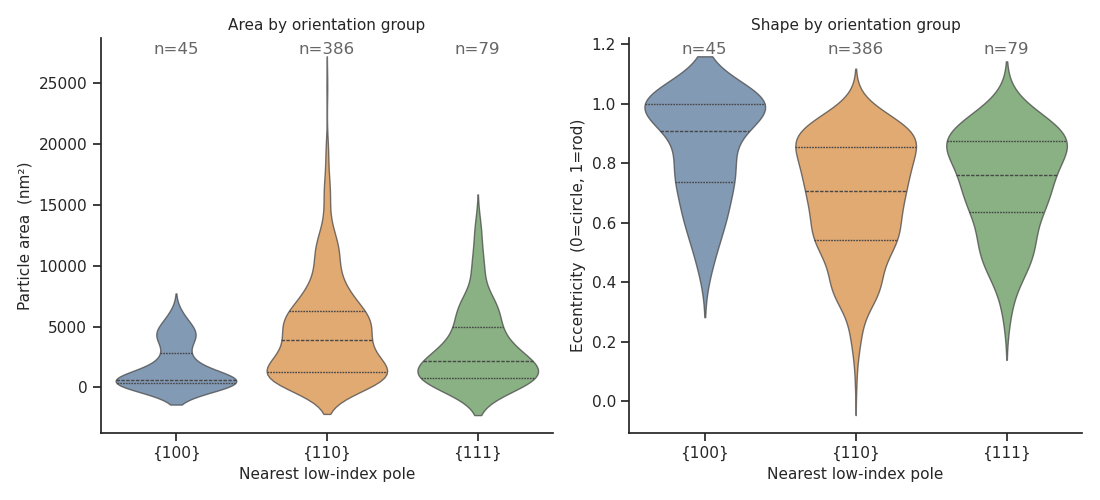

In [24]:
import seaborn as sns

low_index_poles = {
    "{100}": Vector3d([[1,0,0],[0,1,0],[0,0,1]]),
    "{110}": Vector3d([[1,1,0],[1,0,1],[0,1,1],
                       [-1,1,0],[-1,0,1],[0,-1,1]]) / np.sqrt(2),
    "{111}": Vector3d([[1,1,1],[1,1,-1],[1,-1,1],[-1,1,1]]) / np.sqrt(3),
}

def nearest_pole(mean_rot, sym):
    v_crystal = mean_rot * Vector3d([0, 0, 1])
    best_label, best_cos = "{100}", -1.0
    for label, poles in low_index_poles.items():
        cos_vals = np.abs(v_crystal.data @ poles.data.T)
        if cos_vals.max() > best_cos:
            best_cos   = cos_vals.max()
            best_label = label
    return best_label

particle_df["pole_group"] = [
    nearest_pole(r, sym) for r in particle_df["mean_ori"]
]

pole_order = ["{100}", "{110}", "{111}"]
palette    = dict(zip(pole_order, ["#4e79a7", "#f28e2b", "#59a14f"]))

sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, y_col, ylabel, title in [
    (axes[0], "area_nm2",     r"Particle area  (nm²)",           "Area by orientation group"),
    (axes[1], "eccentricity", "Eccentricity  (0=circle, 1=rod)", "Shape by orientation group"),
]:
    # Violin width proportional to number of observations in each group.
    # density_norm="count" is seaborn ≥0.12; use scale="count" for older versions.
    sns.violinplot(data=particle_df, x="pole_group", y=y_col,
                   order=pole_order, palette=palette,
                   density_norm="count",   # wider violin = more particles
                   inner="quartile",       # thin lines at Q1, median, Q3
                   linewidth=1.0,
                   alpha=0.75,
                   ax=ax)

    ax.set_xlabel("Nearest low-index pole", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)

    # Particle count annotation
    for xtick, pole in zip(ax.get_xticks(), pole_order):
        n = (particle_df["pole_group"] == pole).sum()
        ax.text(xtick, ax.get_ylim()[1] * 0.99, f"n={n}",
                ha="center", va="top", fontsize=12, color="0.4")

sns.despine()
plt.tight_layout()
plt.show()

In [25]:
fig.savefig('ClosestZA_linked_area_shape_violin.png',dpi=300)